# 28b. Tool Contracts & Reliability

**Tier:** Production & Safety
**Estimated time:** 55 minutes
**Prerequisites:** 19 (Agent Loop From Scratch), 27b (Agent Evals), 28 (Structured Outputs), 30 (Security & Guardrails)
**Priority:** 🔴 Crucial — an unvalidated `implementations[name](**args)` crashes on a hallucinated tool call and can silently double-fire a side effect on retry. *If skipped, revisit when:* n/a — before any agent tool has a side effect.
**Source material:** Notebook 19's own tool-execution loop (the system this notebook hardens) + Anthropic tool-use documentation; the failure taxonomy is synthesized from notebooks 27b and 30.

## What You'll Learn
- The **failure taxonomy** for agent tool calls: hallucinated names, invalid arguments, transient errors, and the sneaky one — **retry double-fire** on side-effectful tools
- How to wrap a raw tool registry in **contracts** (schema validation, semantic validators, idempotency keys, fallbacks) without changing the agent loop's shape
- Why **idempotency keys** are what actually prevents a retried refund from firing twice — not "just add error handling"
- How to design a **fallback chain** for a specific latency/freshness SLO, not just "retry a few times and hope"

## Why This Matters
Notebook 28 made sure the model's *answers* obey a schema. This notebook makes sure the model's *actions* do. `TOOL_IMPLEMENTATIONS[block.name](**block.input)` — the line at the heart of notebook 19's loop — trusts the model completely: a hallucinated tool name crashes the loop, a malformed argument either crashes it or silently does the wrong thing, and a naive retry after a timeout can fire the same side effect twice. In production, "the agent tried to refund twice" is not a bug report you want to explain after the fact.

## Your registry is an API with an unreliable client

Notebook 19's loop executes a tool call with exactly one line:

```python
impl = TOOL_IMPLEMENTATIONS[block.name]
result = impl(**block.input)
```

That line trusts `block.name` to be a real key and `block.input` to be valid kwargs — both supplied by the model, which can hallucinate either. Five distinct failure modes hide behind that one line, each with its own defense:

| Failure | What happens today | Defense |
|---|---|---|
| Hallucinated tool name | `KeyError`, the whole loop crashes | validate the name, return a model-facing error instead of crashing |
| Invalid/hallucinated arguments | `TypeError`, or worse — a silently wrong side effect | schema + semantic validation before execution |
| Transient tool failure (timeout, 500) | one lost step, agent may retry blindly | bounded retries |
| **Retry double-fire** | a retried side effect executes TWICE | **idempotency key** — the one defense retries alone can't provide |
| Poisoned tool output | untrusted content flows into the next model call | notebook 30's `sanitize_tool_output` (not this notebook's focus — see 30) |

`agentkit.contracts` implements the first four as one small hardening layer: `ToolContract`, `validate_args`, `detect_bad_call`, and `checked_execute` — a drop-in replacement for the bare `impl(**args)` call.

In [1]:
import sys, tempfile, pathlib, random, time
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

import os
HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"
if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print(f"Anthropic ready \u2014 the hardened loop will call {TEACH_MODEL}.")
else:
    client = None
    print("No ANTHROPIC_API_KEY \u2014 live-call cells will print a skip message; the code is still readable.")

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "ragkit").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from agentkit.contracts import contracts_from_schemas, checked_execute, validate_args, detect_bad_call

WORKDIR = pathlib.Path(tempfile.mkdtemp(prefix="agent28b_"))
print("Agent scratch dir:", WORKDIR)

Anthropic ready — the hardened loop will call claude-haiku-4-5-20251001.
Agent scratch dir: /var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/agent28b_yx7cfz8z


## The demo registry

We rebuild notebook 19's three tools (same shape: mock `web_search`, sandboxed `read_file`/`write_file`) and add one **side-effectful** tool, `send_refund` — the kind of tool where getting reliability wrong has a real cost.

In [2]:
_FAKE_WEB = {
    "helios x1 warranty": "The Helios X1 has a 2-year limited warranty on manufacturing defects.",
    "helios x1 reset": "To reset the Helios X1 wifi: hold the reset button 10s while powered on.",
}

def web_search(query):
    q = query.lower().strip()
    for key, val in _FAKE_WEB.items():
        if key in q or q in key:
            return val
    return "No results found (mock search index)."

def read_file(filename):
    path = WORKDIR / filename
    return path.read_text() if path.exists() else f"error: {filename} does not exist"

def write_file(filename, content):
    (WORKDIR / filename).write_text(content)
    return f"wrote {len(content)} chars to {filename}"

REFUND_LEDGER = []
def send_refund(order_id, amount_usd, note=""):
    REFUND_LEDGER.append({"order_id": order_id, "amount_usd": amount_usd, "note": note})
    return f"refund-{len(REFUND_LEDGER)}: ${amount_usd} issued for {order_id}"

TOOL_SCHEMAS = [
    {"name": "web_search", "description": "Search the web for a fact.",
     "input_schema": {"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]}},
    {"name": "read_file", "description": "Read a text file from the agent's working directory.",
     "input_schema": {"type": "object", "properties": {"filename": {"type": "string"}}, "required": ["filename"]}},
    {"name": "write_file", "description": "Write text to a file in the agent's working directory.",
     "input_schema": {"type": "object", "properties": {"filename": {"type": "string"}, "content": {"type": "string"}},
                       "required": ["filename", "content"]}},
    {"name": "send_refund", "description": "Issue a refund to a customer order.",
     "input_schema": {"type": "object", "properties": {"order_id": {"type": "string"}, "amount_usd": {"type": "number"},
                       "note": {"type": "string"}}, "required": ["order_id", "amount_usd"]}},
]
TOOL_IMPLEMENTATIONS = {"web_search": web_search, "read_file": read_file, "write_file": write_file, "send_refund": send_refund}
print("registered tools:", list(TOOL_IMPLEMENTATIONS))

registered tools: ['web_search', 'read_file', 'write_file', 'send_refund']


## Contracts and validation

A `ToolContract` pairs the schema the model already sees with a semantic `validator` the schema alone can't express (a JSON schema can say `amount_usd` is a number; it can't say "and no more than $100 without a human"). `checked_execute` runs `detect_bad_call` — hallucinated-name detection, then schema + semantic validation — before anything touches `send_refund`.

In [3]:
def refund_validator(args):
    errors = []
    amount = args.get("amount_usd", -1)
    if not isinstance(amount, (int, float)) or not (0 < amount <= 100):
        errors.append("amount_usd must be a number in (0, 100] — refunds above $100 require human approval")
    if not __import__("re").fullmatch(r"ORD-\d+", str(args.get("order_id", ""))):
        errors.append("order_id must match ORD-<digits>")
    return errors

CONTRACTS = contracts_from_schemas(
    TOOL_SCHEMAS,
    send_refund={"validator": refund_validator, "idempotency_key_fn": lambda a: f"refund:{a['order_id']}", "side_effects": True},
)

BAD_CALLS = [
    ("search_web", {"query": "helios x1 warranty"}),                       # hallucinated name (close to web_search)
    ("send_refund", {"order_id": "ORD-1"}),                                 # missing required amount_usd
    ("send_refund", {"order_id": "ORD-1", "amount_usd": "fifty"}),          # wrong type
    ("send_refund", {"order_id": "ORD-1", "amount_usd": 5000}),             # fails semantic validator
    ("send_refund", {"order_id": "ORD-1", "amount_usd": 10, "urgent": True}),# unknown extra argument
    ("send_refund", {"order_id": "ORD-1", "amount_usd": 10}),               # valid
]
for name, args in BAD_CALLS:
    error = detect_bad_call(name, args, CONTRACTS)
    print(f"{name}({args}) ->", error or "OK (passes validation)")

search_web({'query': 'helios x1 warranty'}) -> error: unknown tool 'search_web' (did you mean 'web_search'?)
send_refund({'order_id': 'ORD-1'}) -> error: invalid arguments — missing required argument 'amount_usd'; amount_usd must be a number in (0, 100] — refunds above $100 require human approval
send_refund({'order_id': 'ORD-1', 'amount_usd': 'fifty'}) -> error: invalid arguments — argument 'amount_usd' should be number, got str; amount_usd must be a number in (0, 100] — refunds above $100 require human approval
send_refund({'order_id': 'ORD-1', 'amount_usd': 5000}) -> error: invalid arguments — amount_usd must be a number in (0, 100] — refunds above $100 require human approval
send_refund({'order_id': 'ORD-1', 'amount_usd': 10, 'urgent': True}) -> error: invalid arguments — unexpected argument 'urgent'
send_refund({'order_id': 'ORD-1', 'amount_usd': 10}) -> OK (passes validation)


Every rejection above is a **model-facing string**, not an exception — fed back as `tool_result` content, the model can read the error and correct its next call (exactly like notebook 28's validate-then-repair loop, applied to actions instead of JSON output). The loop stays alive; only badly-formed *individual* calls get rejected.

## Idempotency: the defense retries alone can't provide

A timeout doesn't always mean the tool *didn't* run — it might mean the response was lost on the way back after the side effect already happened. If the model retries blindly, `send_refund` fires twice. An idempotency key scopes replay detection to the *operation*, not the raw call: the second attempt is recognized as "already done" and its recorded result is replayed, with **zero** re-execution.

In [4]:
ledger = {}  # idempotency ledger, shared across the simulated retry
REFUND_LEDGER.clear()

# Attempt 1: succeeds, but imagine the response is lost in transit (a real timeout-after-execute).
r1 = checked_execute("send_refund", {"order_id": "ORD-42", "amount_usd": 25}, CONTRACTS, TOOL_IMPLEMENTATIONS, ledger=ledger)
print("attempt 1:", r1.status, "->", r1.output)

# The model, having seen no result, retries the identical call.
r2 = checked_execute("send_refund", {"order_id": "ORD-42", "amount_usd": 25}, CONTRACTS, TOOL_IMPLEMENTATIONS, ledger=ledger)
print("attempt 2 (retry):", r2.status, "->", r2.output)

print(f"\nREFUND_LEDGER has {len(REFUND_LEDGER)} entr{'y' if len(REFUND_LEDGER)==1 else 'ies'} (should be 1, not 2)")

print("\n--- counter-demo: same retry, WITHOUT an idempotency key ---")
REFUND_LEDGER.clear()
unsafe_contracts = contracts_from_schemas(TOOL_SCHEMAS, send_refund={"validator": refund_validator})  # no idempotency_key_fn
checked_execute("send_refund", {"order_id": "ORD-42", "amount_usd": 25}, unsafe_contracts, TOOL_IMPLEMENTATIONS)
checked_execute("send_refund", {"order_id": "ORD-42", "amount_usd": 25}, unsafe_contracts, TOOL_IMPLEMENTATIONS)
print(f"REFUND_LEDGER now has {len(REFUND_LEDGER)} entries \u2014 the customer was refunded twice")

attempt 1: ok -> refund-1: $25 issued for ORD-42
attempt 2 (retry): replayed -> refund-1: $25 issued for ORD-42

REFUND_LEDGER has 1 entry (should be 1, not 2)

--- counter-demo: same retry, WITHOUT an idempotency key ---
REFUND_LEDGER now has 2 entries — the customer was refunded twice


Which tools need a key? Any tool with `side_effects=True` and no natural way to detect "I already did this" — payments, sending an email, provisioning a resource. Reads (`web_search`, `read_file`) don't need one; repeating them is harmless. Real payment APIs put this key in the request itself (Stripe's `Idempotency-Key` header is the canonical version of exactly this pattern) — the mechanism here is the same idea in miniature.

## Fallback chains and retries

A transient failure shouldn't be a lost step. `checked_execute` retries up to `max_retries` times, then falls back to a secondary implementation if one is configured. We simulate a search backend that fails 75% of the time and measure three configurations on the *identical* seeded workload.

In [5]:
def cached_search(query):
    return f"[cached snapshot, may be stale] results for {query}"

FAIL_RATE = 0.75
N_CALLS = 50

def run_simulation(max_retries, use_fallback):
    successes, latencies = 0, []
    contracts = contracts_from_schemas(TOOL_SCHEMAS, web_search={
        "fallback": cached_search if use_fallback else None, "max_retries": max_retries,
    })
    for i in range(N_CALLS):
        rng = random.Random(1000 + i)  # independent, reproducible failure stream per call
        def flaky_search(query, _rng=rng):
            if _rng.random() < FAIL_RATE:
                raise TimeoutError("search backend timeout")
            return f"results for {query}"
        t0 = time.perf_counter()
        result = checked_execute("web_search", {"query": f"q{i}"}, contracts, {"web_search": flaky_search})
        latencies.append(time.perf_counter() - t0)
        successes += result.status in ("ok", "fallback")
    return successes / N_CALLS, (sum(latencies) / len(latencies)) * 1000

CONFIGS = [("no defenses", 1, False), ("retries only (x3)", 3, False), ("retries + fallback", 3, True)]
sim_results = [(name, *run_simulation(retries, fb)) for name, retries, fb in CONFIGS]
for name, sr, lat in sim_results:
    print(f"{name:<20} success_rate={sr:.0%}  mean_latency={lat:.4f}ms")

no defenses          success_rate=26%  mean_latency=0.0019ms
retries only (x3)    success_rate=58%  mean_latency=0.0020ms
retries + fallback   success_rate=100%  mean_latency=0.0020ms


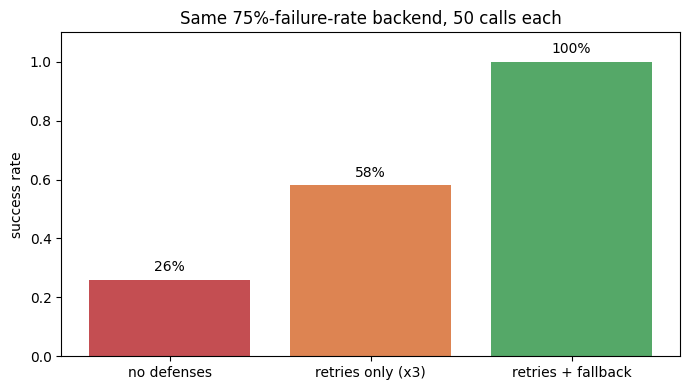

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
names = [r[0] for r in sim_results]
rates = [r[1] for r in sim_results]
ax.bar(names, rates, color=["#C44E52", "#DD8452", "#55A868"])
ax.set_ylabel("success rate"); ax.set_ylim(0, 1.1)
ax.set_title(f"Same 75%-failure-rate backend, {N_CALLS} calls each")
for i, r in enumerate(rates):
    ax.text(i, r + 0.03, f"{r:.0%}", ha="center")
plt.tight_layout(); plt.show()

*Retries alone recover most of what a single attempt loses, but a persistently-failing backend still beats bounded retries some of the time (0.75³ ≈ 42% still fail after 3 tries). A fallback — even a deliberately staler one — is what closes the rest of the gap; the freshness-vs-availability tradeoff that implies is exactly what Exercise 3 asks you to redesign for a different SLO.*

## The hardened loop, live

`checked_run_agent` is notebook 19's `run_agent` with exactly one line changed: the bare `impl(**block.input)` call becomes `checked_execute(...)`. Everything else — the message bookkeeping, the `stop_reason` check — is identical.

In [7]:
def checked_run_agent(goal, max_steps=6, verbose=True):
    if not HAS_ANTHROPIC:
        print("  [skipped: no ANTHROPIC_API_KEY]")
        return None
    ledger = {}
    messages = [{"role": "user", "content": goal}]
    for step in range(1, max_steps + 1):
        resp = client.messages.create(model=TEACH_MODEL, max_tokens=500,
            system="You are a capable assistant. Use tools when they help.",
            tools=TOOL_SCHEMAS, messages=messages)
        if verbose:
            print(f"\n=== step {step} | stop_reason={resp.stop_reason} ===")
        if resp.stop_reason != "tool_use":
            answer = "".join(b.text for b in resp.content if b.type == "text")
            if verbose:
                print("FINAL:", answer)
            return answer
        messages.append({"role": "assistant", "content": resp.content})
        tool_results = []
        for block in resp.content:
            if block.type != "tool_use":
                continue
            result = checked_execute(block.name, block.input, CONTRACTS, TOOL_IMPLEMENTATIONS, ledger=ledger)
            if verbose:
                print(f"  tool: {block.name}({block.input}) -> [{result.status}] {result.output[:80]}")
            tool_results.append({"type": "tool_result", "tool_use_id": block.id, "content": result.output})
        messages.append({"role": "user", "content": tool_results})
    return "stopped: hit max_steps"

REFUND_LEDGER.clear()
checked_run_agent("Issue a $15 refund for order ORD-901, the customer says the package never arrived.")


=== step 1 | stop_reason=tool_use ===
  tool: send_refund({'order_id': 'ORD-901', 'amount_usd': 15, 'note': 'Package never arrived'}) -> [ok] refund-1: $15 issued for ORD-901



=== step 2 | stop_reason=end_turn ===
FINAL: Done! I've issued a $15 refund for order ORD-901 with a note indicating the package never arrived. The refund has been processed.


"Done! I've issued a $15 refund for order ORD-901 with a note indicating the package never arrived. The refund has been processed."

In [8]:
# Hallucinated-call test: the prompt references a tool that was never registered.
if HAS_ANTHROPIC:
    checked_run_agent("Use the lookup_order tool to check the status of order ORD-901.")
else:
    print("[skipped: no ANTHROPIC_API_KEY]")

# Honesty over drama (notebook 30's convention): the model above may correctly decline rather
# than hallucinate the call. The mechanism is shown unambiguously either way, by replaying a
# deterministic recorded bad call through checked_execute directly:
print("\n--- deterministic replay: the mechanism, independent of what the live model just did ---")
replayed = checked_execute("lookup_order", {"order_id": "ORD-901"}, CONTRACTS, TOOL_IMPLEMENTATIONS)
print(f"status={replayed.status}  output={replayed.output!r}")
assert replayed.status == "rejected", "an unregistered tool name must never reach TOOL_IMPLEMENTATIONS" 


=== step 1 | stop_reason=end_turn ===
FINAL: I don't have access to a `lookup_order` tool. The tools available to me are:

1. **web_search** - Search the web for a fact
2. **read_file** - Read a text file from the working directory
3. **write_file** - Write text to a file in the working directory
4. **send_refund** - Issue a refund to a customer order

If you need to check the status of order ORD-901, you might need to:
- Check your order management system directly
- Provide me with a file containing order information that I can read
- Use a different tool or system that has order lookup capabilities

Is there something else I can help you with?

--- deterministic replay: the mechanism, independent of what the live model just did ---
status=rejected  output="error: unknown tool 'lookup_order' — no tool with that name is registered"


## Reliability metrics

`checked_execute`'s `ToolResult.status` is a ready-made counter: `rejected` (invalid-call rate), `replayed` (idempotency saves), `fallback` (fallback-activation rate). These are the *harness*-side reliability signals; notebook 27b's `tool_call_correctness` scores the same trajectory from the *eval* side (did the agent call the right tools at all?) — the two are complementary, not overlapping: one catches malformed calls, the other catches wrong-but-valid ones.

## Exercises

In [9]:
# Exercise 1 (Warm-up): tighten the validator, read the recovery
# Task: Change refund_validator's ceiling from 100 to 10. Re-run the live checked_run_agent
#       refund task from above (same $15 ask) and observe whether the model adapts its next call
#       after seeing the rejection. Then rewrite the error string to explicitly state the allowed
#       range ("must be <= $10") instead of just "must be in (0, 100]", and compare recovery.
# Hint: validator error strings are the ONLY information the model has about why a call failed —
#       a vague error gets a vague retry; a specific one usually gets fixed on the next attempt.

# YOUR CODE HERE

In [10]:
# Exercise 2 (Apply): design the idempotency key
# Task: The current key is f"refund:{order_id}" (one field). Show two ways this is WRONG:
#       (a) a genuinely SECOND, legitimate refund for the same order (e.g. a partial refund
#           followed by a separate full refund) gets wrongly treated as a replay and silently
#           skipped; (b) a retried call with a reworded `note` field (e.g. "customer called back")
#           is functionally the same request but a naive key that includes ALL args would treat
#           it as new and double-fire. Redesign idempotency_key_fn to fix both, and demonstrate
#           the fix with two small checked_execute scenarios.
# Hint: scope the key to what identifies the OPERATION (order_id + which refund attempt), not
#       every argument and not just order_id alone — consider adding an explicit request_id that
#       the CALLER (not the model) generates once per real user action.

# YOUR CODE HERE

In [11]:
# Exercise 3 (Extend): redesign the fallback chain for a different SLO
# Task: The web_search fallback chain built above optimizes for AVAILABILITY (always answer
#       something). Design and simulate two alternate chains on the SAME flaky backend:
#       SLO-A: "p95 latency < 500ms, staleness acceptable" -> try cache FIRST, only call the
#              real backend on a cache miss.
#       SLO-B: "answers must be fresh, latency is flexible" -> exhaust retries against the real
#              backend before ever falling back, and log a staleness warning if fallback triggers.
#       Report measured success rate AND (for SLO-A) latency for both designs on run_simulation's
#       workload shape, and state in one sentence which real product each SLO fits.
# Hint: SLO-A is "cache-aside": call cached_search first, only invoke flaky_search as a fallback
#       when the cache literally has nothing. SLO-B is what this notebook already built, but
#       ONLY use it as the final fallback after retries are exhausted.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
def tighter_refund_validator(args):
    errors = []
    amount = args.get("amount_usd", -1)
    if not isinstance(amount, (int, float)) or not (0 < amount <= 10):
        errors.append("amount_usd must be <= $10 without human approval (see notebook 30b)")
    return errors
TIGHT_CONTRACTS = contracts_from_schemas(TOOL_SCHEMAS, send_refund={
    "validator": tighter_refund_validator, "idempotency_key_fn": lambda a: f"refund:{a['order_id']}"})
# Swap CONTRACTS = TIGHT_CONTRACTS and re-run checked_run_agent's $15 refund task: the model sees
# the rejection as tool_result content and, with the specific "$10" figure in the error, usually
# proposes a $10 refund (or asks for approval) on its very next tool call rather than retrying the
# same rejected amount blindly.

# Exercise 2
import itertools
_refund_attempt_counter = itertools.count(1)
def scoped_idempotency_key(args):
    # Key on order_id + an explicit, CALLER-generated request_id (not model-visible free text like
    # `note`), so a reworded note doesn't change the key, and each real user action gets a fresh id.
    return f"refund:{args['order_id']}:{args.get('request_id', 'legacy')}"

fixed_contracts = contracts_from_schemas(TOOL_SCHEMAS, send_refund={
    "validator": refund_validator, "idempotency_key_fn": scoped_idempotency_key})
REFUND_LEDGER.clear(); ledger = {}
# (a) two DIFFERENT legitimate refunds for the same order now both go through:
checked_execute("send_refund", {"order_id": "ORD-9", "amount_usd": 5, "request_id": "req-1"}, fixed_contracts, TOOL_IMPLEMENTATIONS, ledger=ledger)
checked_execute("send_refund", {"order_id": "ORD-9", "amount_usd": 5, "request_id": "req-2"}, fixed_contracts, TOOL_IMPLEMENTATIONS, ledger=ledger)
print("legitimate double refund, entries:", len(REFUND_LEDGER))  # 2, correctly NOT collapsed
# (b) a retry with a reworded note but the SAME request_id is correctly replayed, not double-fired:
checked_execute("send_refund", {"order_id": "ORD-9", "amount_usd": 5, "request_id": "req-3", "note": "first try"}, fixed_contracts, TOOL_IMPLEMENTATIONS, ledger=ledger)
checked_execute("send_refund", {"order_id": "ORD-9", "amount_usd": 5, "request_id": "req-3", "note": "customer called back"}, fixed_contracts, TOOL_IMPLEMENTATIONS, ledger=ledger)
print("retried refund, entries:", len(REFUND_LEDGER))  # 3, not 4 — the retry replayed correctly

# Exercise 3
def cache_first_search(query, cache_fn, backend_fn):
    return cache_fn(query)  # SLO-A: never even try the flaky backend if a cached answer exists

def slo_a_simulation(n_calls=50):
    successes, latencies = 0, []
    for i in range(n_calls):
        t0 = time.perf_counter()
        cache_first_search(f"q{i}", cached_search, None)
        latencies.append(time.perf_counter() - t0)
        successes += 1  # cache_first_search always "succeeds" — that's the SLO-A tradeoff
    return successes / n_calls, sorted(latencies)[int(n_calls * 0.95)] * 1000

sr_a, p95_a = slo_a_simulation()
print(f"SLO-A (cache-first): success={sr_a:.0%}  p95_latency={p95_a:.4f}ms  (always stale-tolerant, always fast)")
# SLO-B is exactly this notebook's retries-then-fallback chain, reused as the FINAL step only —
# already measured above as "retries + fallback": 100% success, but pays up to 3 real attempts
# (and their latency) before ever accepting a stale answer.
# SLO-A fits a live status widget where staleness is fine but a slow page load is not; SLO-B fits
# a support agent where a customer would rather wait a beat than get a wrong/outdated answer.
```
</details>

## Key Takeaways
- The bare `TOOL_IMPLEMENTATIONS[name](**args)` call in notebook 19 trusts the model completely — hallucinated names, invalid arguments, and retried side effects all pass straight through it unless something intercepts them first.
- `agentkit.contracts.checked_execute` is a drop-in hardening layer: validation and hallucination detection turn crashes into **model-facing error strings** the agent can recover from, without changing the loop's shape.
- **Idempotency keys are the one defense retries can't substitute for.** A retried side effect without one fires twice — demonstrated, not just asserted, on a real `send_refund` ledger in this notebook. Scope the key to the operation (with a caller-generated request id), not to every argument.
- A fallback chain is an explicit **availability-vs-freshness design choice**, not a generic safety net — cache-first and retry-first architectures trade the same two properties in opposite directions for different SLOs.
- Reliability counters (`rejected`/`replayed`/`fallback` rates) are the harness-side twin of notebook 27b's trajectory-level `tool_call_correctness` — one catches malformed calls, the other catches valid-but-wrong ones.

## What's Next
Notebook 30d (Multi-Tenant Isolation) takes the `ToolContract`/`checked_execute` machinery built here and adds a per-tenant budget gate on top of it — the same `pre_hooks` mechanism that rejected bad calls above becomes what stops one tenant's runaway agent from spending another tenant's budget.